In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from src import config
from src.movements import Movements, Operations, Timeseries, SpendingPatterns
from src.graphics import Plots

In [3]:
# Instantiate configuration
plots_backend = "matplotlib"
cfg = config.Constants("./config/config.json")

## Operations: Aggregated Expenses Volume

In [4]:
# Instantiate and set up operations class
operations = Operations(cfg)
operations.setup()

# Print the expected monthly delta
operations.print_expected_delta()

Expected Delta = 372.58 EUR / Month


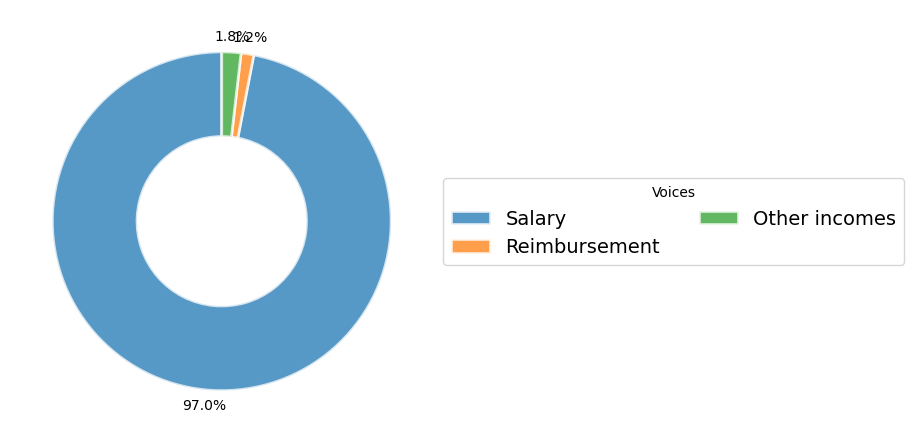

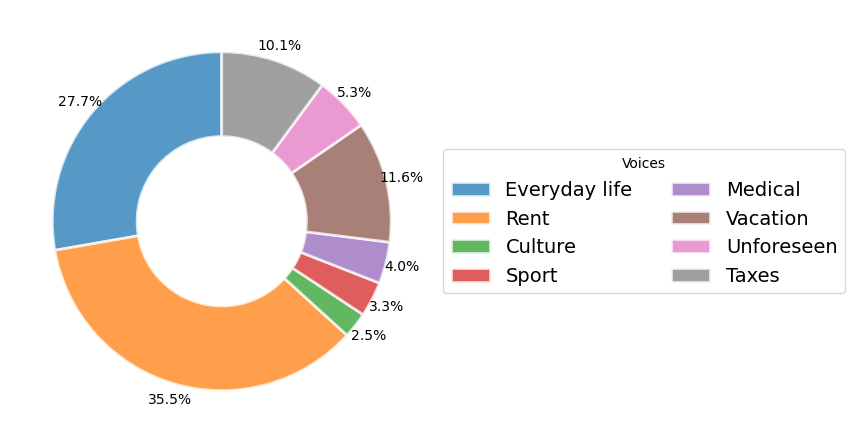

In [5]:
# Plot the income/expense voices
fig_incomes, fig_expenses = Plots.plot_expense_items(operations, backend = plots_backend)

if plots_backend == "plotly":
    fig_incomes.show()
    fig_expenses.show()

## Timeseries: Deduction of the linear growth trend

In [8]:
# Instantiate and set up timeseries class
timeseries = Timeseries(cfg)
timeseries.setup()

# Fit the trendline coefficients
timeseries.fit_trendline_coefficients()

# Print yearly statistics
timeseries.sumup_printout()


       Summary statistic year 2024 Amount (EUR)
0   Initial stock (at 2024-01-01)      5000.15
1     Final stock (at 2024-12-31)      9471.15
2                   Average stock      7875.42
3  Estimated daily capital growth        12.22


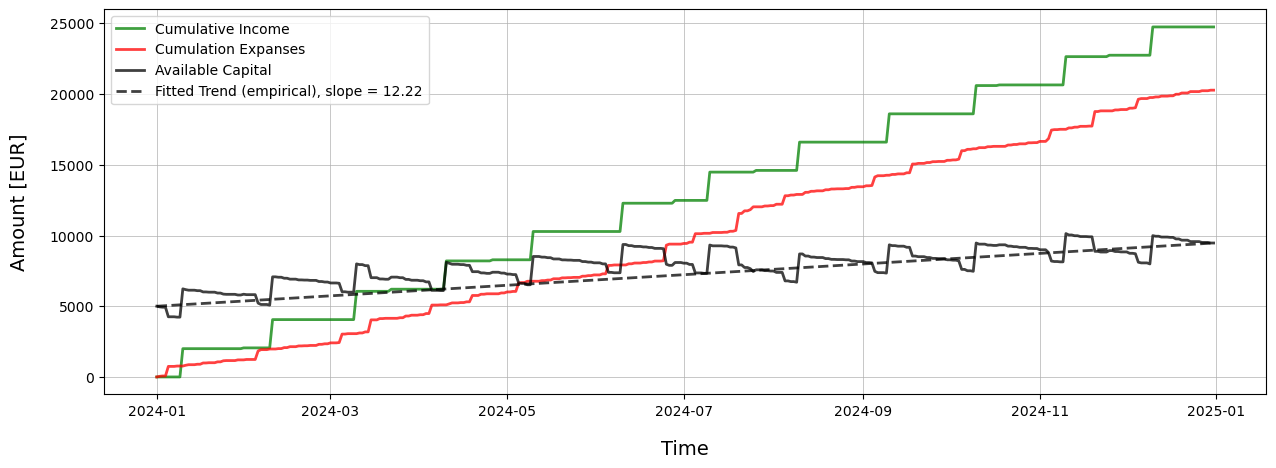

In [9]:
# Plot the timeseries reconstruction
fig_timeseries = Plots.plot_trend(timeseries, backend = plots_backend)

if plots_backend == "plotly":
    fig_timeseries.show()

## Future Simulations

In [11]:
# Extrapolate the spending patterns of the selected year
spending_patterns = SpendingPatterns(cfg)
spending_patterns.fit()

# Perform and ahead-in-time simulation
simulated_inout = spending_patterns.simulate_yearly_expenses(rules = cfg.SIMULATION_COLUMNS_CONSTANTS)

100%|██████████████████████████████████████████████████████████████████████████████████| 10/10 [00:00<00:00, 13.76it/s]


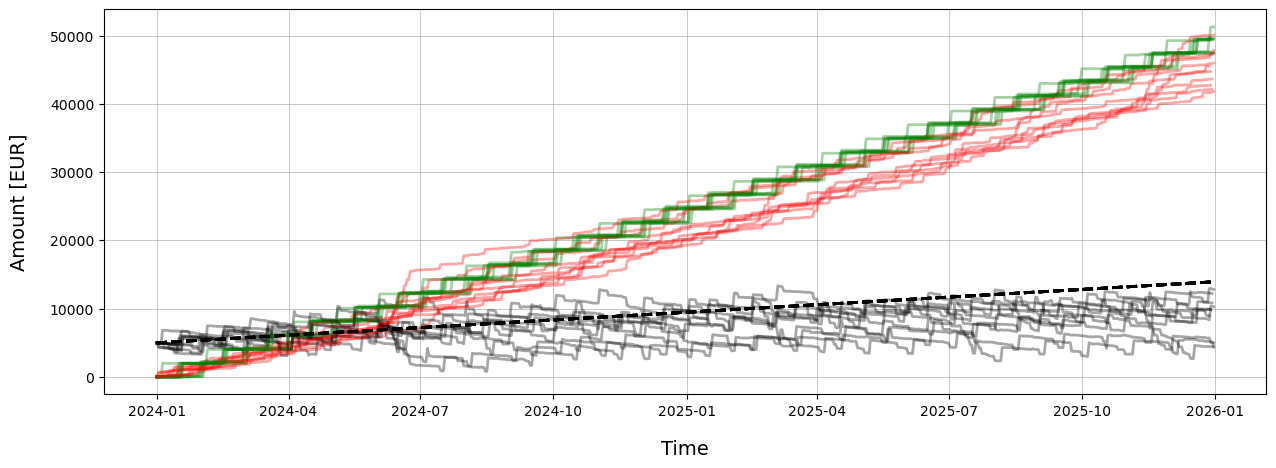

In [12]:
# Instantiate Timeseries classes to host source simulated data
simulated_inout_timeseries = []
for inout in simulated_inout:
    _timeseries = Timeseries(cfg)
    _timeseries.setup(inout)
    simulated_inout_timeseries.append(_timeseries.inout_sheet)

# Plot the simulation runs
fig_simulations = Plots.plot_simulation_runs(
    simulated_inout_timeseries,
    trendline_params = timeseries.estimated_lm_params,
    plot_trend_line = True
)

if plots_backend == "plotly":
    fig_simulations.show()